# This notebook shows how to compute atom-projection operators and apply them to wavefunctions
### Import the necessary libraries

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from elkpy.structure import Structure

### The atom-projection operator
The muffin-tin partition of the unit cell (one sphere per atom, plus the interstitial region between them) is exact, so for any two states $\psi_i,\psi_j$ of the same diagonalization
$$ (P_\alpha)_{ij}=\langle\psi_i|\hat P_\alpha|\psi_j\rangle=\int_{{\rm MT}_\alpha}\psi_i^*(\mathbf r)\,\psi_j(\mathbf r)\,d^3r, \qquad \sum_\alpha P_\alpha+P_{\rm interstitial}=\mathbb 1 $$
$P_\alpha$ is Hermitian and positive semi-definite (a Gram matrix restricted to a sub-volume); its diagonal is each state's fractional weight on atom $\alpha$'s muffin tin, its off-diagonal genuinely mixes two different eigenstates of the SAME diagonalization -- the piece that makes this an operator, not just a weight table.

In [2]:
SI_AVEC = [(5.13, 5.13, 0.00), (5.13, 0.00, 5.13), (0.00, 5.13, 5.13)]
SI_SPECIES = {"Si": [(0.0, 0.0, 0.0), (0.25, 0.25, 0.25)]}
si = Structure(SI_AVEC, SI_SPECIES).get_calculation("_scratch/si_atomproj", xc="PW", ngridk=(4, 4, 4))

proj = si.get_atom_projection((0.1, 0.2, 0.05), ist0=1, ist1=4)
proj.matrices.shape  # (natmtot, nst, nst)

(2, 4, 4)

### Applying $P_\alpha$ to a wavefunction: N vs. B character in monolayer h-BN
The more electronegative N pulls the bonding ($\pi$, valence-top) state's weight toward itself; the antibonding ($\pi^*$, conduction-bottom) state is B-dominated instead -- a sharp, sign-of-the-effect prediction, checked at the K point where the direct gap sits.

In [3]:
A, VACUUM = 4.743210000, 20.0  # Bohr, same hBN slab as 05_berry_curvature.ipynb
HBN_AVEC = [(A, 0.0, 0.0), (-A / 2, A * 3 ** 0.5 / 2, 0.0), (0.0, 0.0, VACUUM)]
HBN_SPECIES = {"B": [(1 / 3, 2 / 3, 0.5)], "N": [(2 / 3, 1 / 3, 0.5)]}

hbn = Structure(HBN_AVEC, HBN_SPECIES).get_calculation("_scratch/hbn_atomproj", xc="PW", ngridk=(6, 6, 1), rgkmax=7.0)
hbn.get_energy()

import re
first_block = (hbn.workdir / "EIGVAL.OUT").read_text().split("k-point")[1]
state_line = re.compile(r"^\s*\d+\s+(\S+)\s+(\S+)\s*$")
occ = [float(m.group(2)) for m in map(state_line.match, first_block.splitlines()) if m]
ist1 = sum(o > 1.0 for o in occ)  # occupied count from EIGVAL.OUT, not an assumed electron count

In [4]:
K = (1 / 3, 1 / 3, 0)
proj_k = hbn.get_atom_projection(K, ist0=ist1, ist1=ist1 + 1)  # valence top, conduction bottom
n, b = hbn.structure.atom_index("N"), hbn.structure.atom_index("B")

weights = {
    "N": [proj_k.matrices[n][0, 0].real, proj_k.matrices[n][1, 1].real],
    "B": [proj_k.matrices[b][0, 0].real, proj_k.matrices[b][1, 1].real],
}
print(weights)

{'N': [np.float64(0.5218761525987071), np.float64(0.015016603943406365)], 'B': [np.float64(0.010619368177884688), np.float64(0.32451565407649297)]}


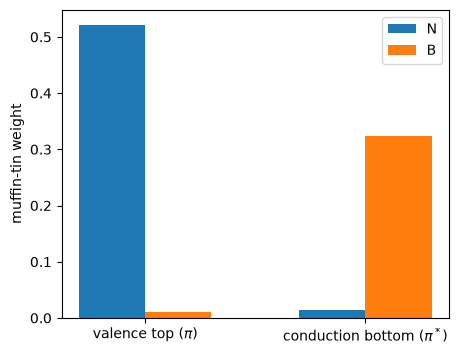

In [5]:
x = np.arange(2)
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(x - 0.15, weights["N"], width=0.3, label="N")
ax.bar(x + 0.15, weights["B"], width=0.3, label="B")
ax.set_xticks(x)
ax.set_xticklabels([r"valence top ($\pi$)", r"conduction bottom ($\pi^*$)"])
ax.set_ylabel("muffin-tin weight")
ax.legend()
plt.show()